In [1]:
!pip install tensorflow

In [2]:
!pip install medmnist

In [3]:
import os
import numpy as np

# 1. Khai báo và tạo thư mục 'data' nằm ngay trong thư mục project hiện tại
PROJECT_DATA_DIR = './../data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)

# =========================================================
# 2. TẢI DIGIT MNIST VÀ FASHION MNIST
# =========================================================
# MẸO: Ép thư viện Keras đổi "nhà" từ ổ đĩa hệ thống sang thư mục project của bạn
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import mnist, fashion_mnist

print("Đang tải Digit MNIST vào project...")
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

print("Đang tải Fashion MNIST vào project...")
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()
# Keras sẽ tự động tạo một thư mục con tên là 'datasets' bên trong thư mục 'data' của bạn.
# Các file tải về sẽ nằm ở: ./data/datasets/


# =========================================================
# 3. TẢI PNEUMONIA MNIST (MEDICAL)
# =========================================================
import medmnist
from medmnist import PneumoniaMNIST

print("Đang tải Pneumonia MNIST vào project...")
# Với MedMNIST, chỉ cần truyền biến root là xong
train_pneumonia = PneumoniaMNIST(split='train', download=True, root=PROJECT_DATA_DIR)
test_pneumonia  = PneumoniaMNIST(split='test',  download=True, root=PROJECT_DATA_DIR)

# Trích xuất ra ma trận Numpy
X_train_pneumonia = train_pneumonia.imgs
y_train_pneumonia = train_pneumonia.labels.squeeze()

X_test_pneumonia = test_pneumonia.imgs
y_test_pneumonia = test_pneumonia.labels.squeeze()

print("\n🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục:", PROJECT_DATA_DIR)

Đang tải Digit MNIST vào project...
Đang tải Fashion MNIST vào project...
Đang tải Pneumonia MNIST vào project...

🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục: ./../data


In [4]:
import numpy as np

def describe_raw(name, X, y):
    print(f"\n{name}")
    print(f"  X shape: {X.shape}, dtype: {X.dtype}")
    print(f"  y shape: {y.shape}, dtype: {y.dtype}")
    print(f"  X min/max: {X.min()} / {X.max()}")
    print(f"  Unique labels: {np.unique(y)}")

describe_raw("Digit MNIST (raw)", X_train_digit, y_train_digit)
describe_raw("Fashion MNIST (raw)", X_train_fashion, y_train_fashion)
describe_raw("Pneumonia MNIST (raw)", X_train_pneumonia, y_train_pneumonia)


Digit MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Fashion MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]

Pneumonia MNIST (raw)
  X shape: (4708, 28, 28), dtype: uint8
  y shape: (4708,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1]


Tổng số ảnh Digit: 70000


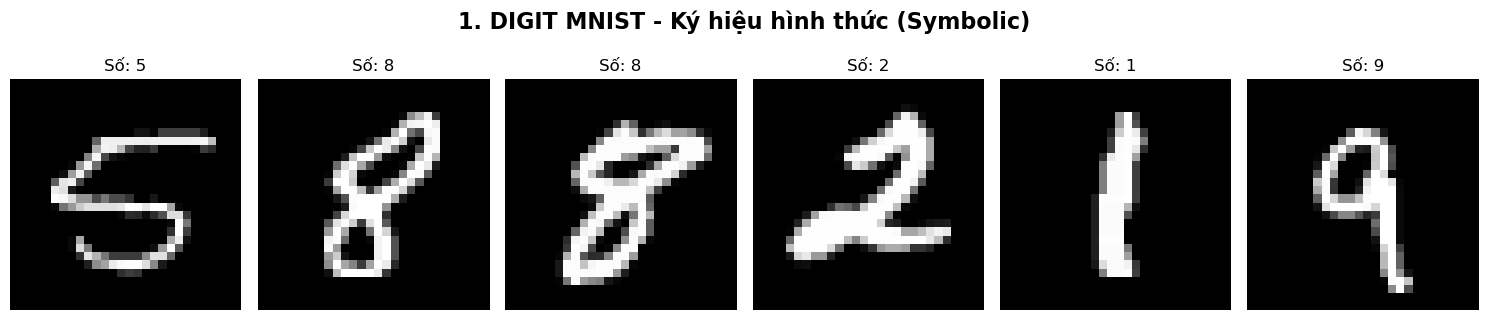

Tổng số ảnh Fashion: 70000


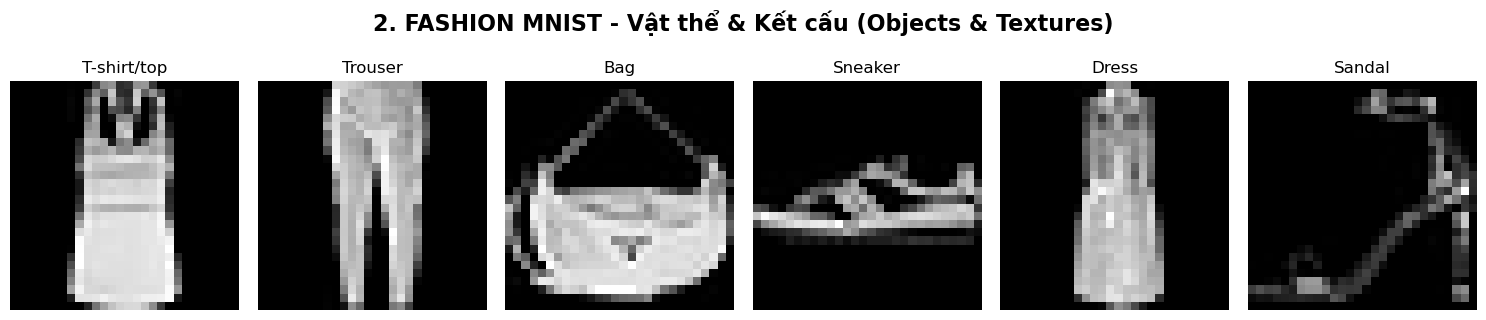

Tổng số ảnh Pneumonia: 5332


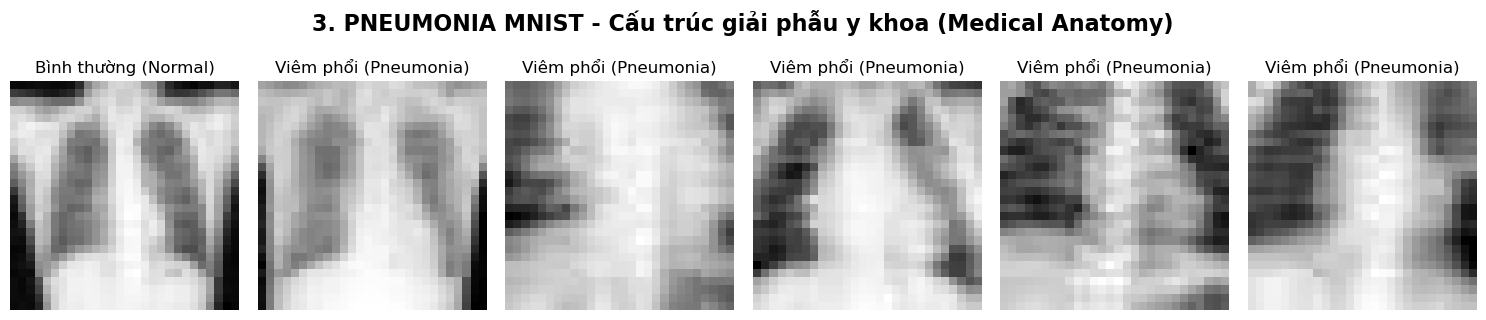

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GỘP TẬP TRAIN VÀ TEST ĐỂ LÀM EDA
# ==========================================
X_digit = np.concatenate((X_train_digit, X_test_digit), axis=0)
y_digit = np.concatenate((y_train_digit, y_test_digit), axis=0)

X_fashion = np.concatenate((X_train_fashion, X_test_fashion), axis=0)
y_fashion = np.concatenate((y_train_fashion, y_test_fashion), axis=0)

X_pneumonia = np.concatenate((X_train_pneumonia, X_test_pneumonia), axis=0)
y_pneumonia = np.concatenate((y_train_pneumonia, y_test_pneumonia), axis=0)

# Định nghĩa tên nhãn cho dễ nhìn
fashion_names = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
                 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
pneumonia_names = {0: 'Bình thường (Normal)', 1: 'Viêm phổi (Pneumonia)'}

# ==========================================
# 2. HÀM VẼ LƯỚI ẢNH NGẪU NHIÊN
# ==========================================
def plot_random_samples(X, y, title, label_dict=None, num_samples=5):
    """Hàm vẽ ngẫu nhiên một số ảnh từ tập dữ liệu"""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    
    # Lấy ngẫu nhiên 'num_samples' chỉ số (index)
    random_indices = np.random.choice(X.shape[0], num_samples, replace=False)
    
    for i, idx in enumerate(random_indices):
        img = X[idx]
        label = y[idx]
        
        # Chuyển đổi nhãn số thành tên (nếu có dictionary)
        label_name = label_dict[label] if label_dict else f"Số: {label}"
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(label_name, fontsize=12)
        axes[i].axis('off') # Tắt trục tọa độ cho đẹp
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. THỰC THI VẼ BIỂU ĐỒ
# ==========================================
print(f"Tổng số ảnh Digit: {X_digit.shape[0]}")
plot_random_samples(X_digit, y_digit, "1. DIGIT MNIST - Ký hiệu hình thức (Symbolic)", num_samples=6)

print(f"Tổng số ảnh Fashion: {X_fashion.shape[0]}")
plot_random_samples(X_fashion, y_fashion, "2. FASHION MNIST - Vật thể & Kết cấu (Objects & Textures)", label_dict=fashion_names, num_samples=6)

print(f"Tổng số ảnh Pneumonia: {X_pneumonia.shape[0]}")
plot_random_samples(X_pneumonia, y_pneumonia, "3. PNEUMONIA MNIST - Cấu trúc giải phẫu y khoa (Medical Anatomy)", label_dict=pneumonia_names, num_samples=6)

## EDA pipeline (tao figure + thong ke)
Chay cac cell ben duoi de tao lai toan bo figure va so lieu dung trong bao cao.

In [6]:
# Neu thieu thu vien thi chay cell nay
!pip -q install seaborn scikit-image scikit-learn opencv-python

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from skimage.metrics import structural_similarity as ssim
from skimage.feature import hog, graycomatrix, graycoprops

RANDOM_STATE = 42
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

def to_float(images):
    images = images.astype("float32")
    if images.max() > 1.0:
        images = images / 255.0
    return images

In [8]:
# Gop va chuan hoa
X_digit_raw = np.concatenate((X_train_digit, X_test_digit), axis=0)
y_digit = np.concatenate((y_train_digit, y_test_digit), axis=0)
X_fashion_raw = np.concatenate((X_train_fashion, X_test_fashion), axis=0)
y_fashion = np.concatenate((y_train_fashion, y_test_fashion), axis=0)
X_pneumonia_raw = np.concatenate((X_train_pneumonia, X_test_pneumonia), axis=0)
y_pneumonia = np.concatenate((y_train_pneumonia, y_test_pneumonia), axis=0)

X_digit = to_float(X_digit_raw)
X_fashion = to_float(X_fashion_raw)
X_pneumonia = to_float(X_pneumonia_raw)

### 1) Thong ke thong tin ban dau

In [9]:
summary_df = pd.DataFrame(
    [
        {
            "Dataset": "Digit MNIST",
            "Train": len(X_train_digit),
            "Test": len(X_test_digit),
            "Classes": len(np.unique(y_digit)),
            "Size": str(X_train_digit.shape[1:]),
            "Value range": f"[{X_train_digit.min()}, {X_train_digit.max()}]",
        },
        {
            "Dataset": "Fashion MNIST",
            "Train": len(X_train_fashion),
            "Test": len(X_test_fashion),
            "Classes": len(np.unique(y_fashion)),
            "Size": str(X_train_fashion.shape[1:]),
            "Value range": f"[{X_train_fashion.min()}, {X_train_fashion.max()}]",
        },
        {
            "Dataset": "PneumoniaMNIST",
            "Train": len(X_train_pneumonia),
            "Test": len(X_test_pneumonia),
            "Classes": len(np.unique(y_pneumonia)),
            "Size": str(X_train_pneumonia.shape[1:]),
            "Value range": f"[{X_train_pneumonia.min()}, {X_train_pneumonia.max()}]",
        },
    ]
 )
summary_df

,Dataset,Train,Test,Classes,Size,Value range
0,Digit MNIST,60000,10000,10,"(28, 28)","[0, 255]"
1,Fashion MNIST,60000,10000,10,"(28, 28)","[0, 255]"
2,PneumoniaMNIST,4708,624,2,"(28, 28)","[0, 255]"


**Nhan xet:** Kich thuoc anh dong nhat 28x28, nhung so luong mau va so luong lop khac nhau giua cac tap.

### 2) Phan phoi nhan

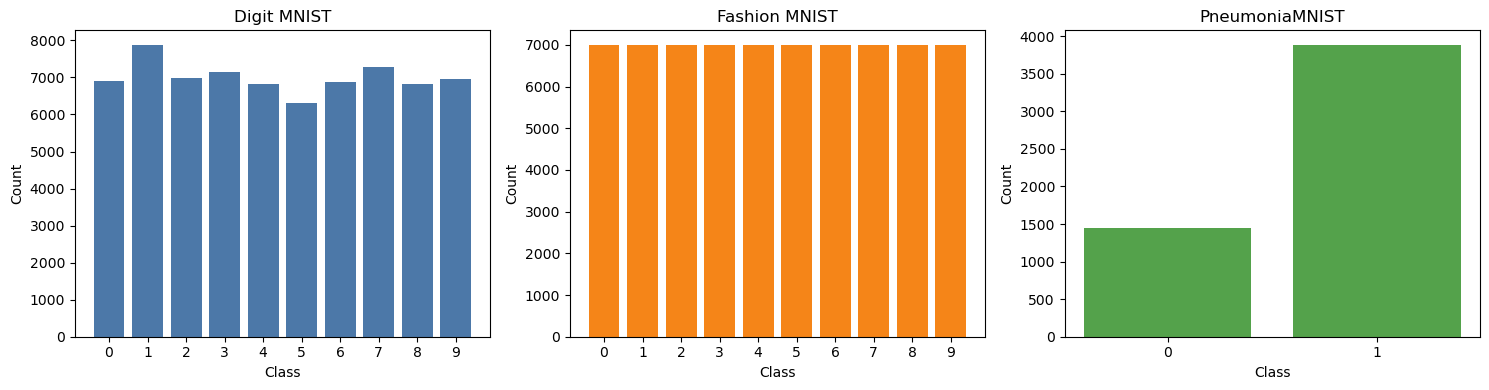

In [10]:
datasets_map = {
    "Digit MNIST": (y_digit, "#4C78A8"),
    "Fashion MNIST": (y_fashion, "#F58518"),
    "PneumoniaMNIST": (y_pneumonia, "#54A24B"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (labels, color)) in zip(axes, datasets_map.items()):
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(FIG_DIR / "label_distribution.png", dpi=300)
plt.show()

**Nhan xet:** Digit/Fashion can bang nhan tuong doi, trong khi PneumoniaMNIST lech lop ro rang (xem figure label_distribution.png).

### 3) Phan phoi cuong do diem anh (histogram + pie)

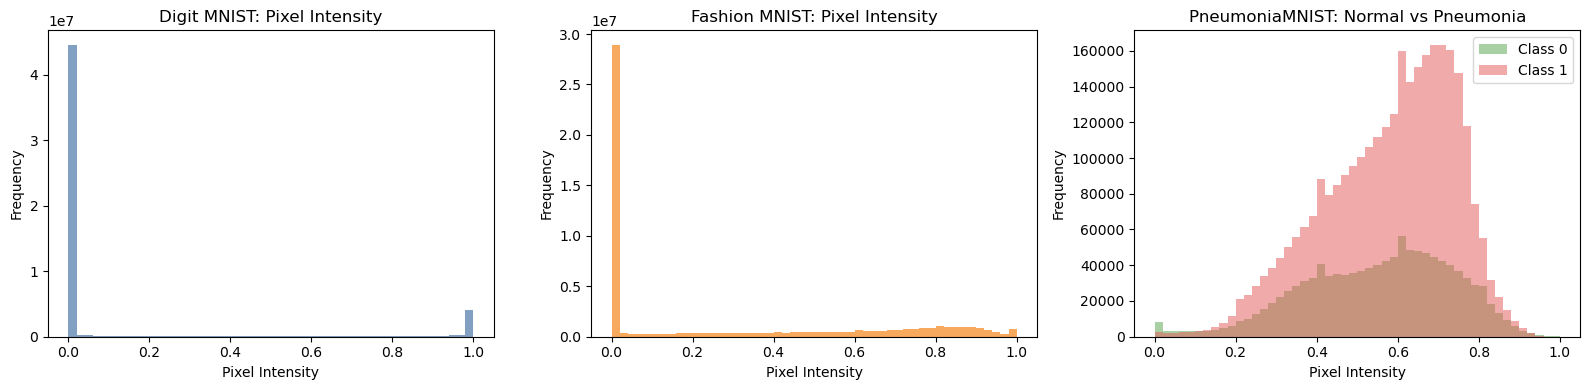

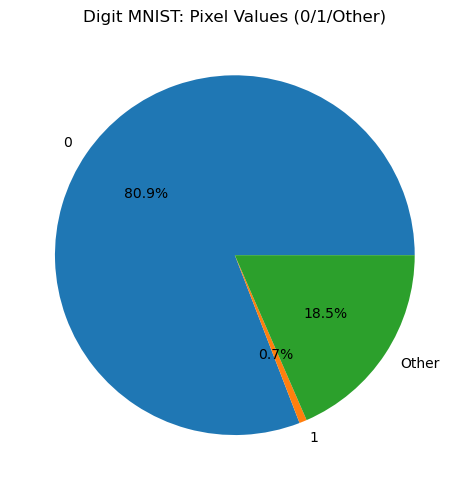

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(X_digit.ravel(), bins=50, color="#4C78A8", alpha=0.7)
axes[0].set_title("Digit MNIST: Pixel Intensity")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_fashion.ravel(), bins=50, color="#F58518", alpha=0.7)
axes[1].set_title("Fashion MNIST: Pixel Intensity")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

for cls, color in zip([0, 1], ["#54A24B", "#E45756"]):
    pixels = X_pneumonia[y_pneumonia == cls].ravel()
    axes[2].hist(pixels, bins=50, alpha=0.5, color=color, label=f"Class {cls}")
axes[2].set_title("PneumoniaMNIST: Normal vs Pneumonia")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Frequency")
axes[2].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "pixel_histogram_digit_pneumonia.png", dpi=300)
plt.show()

flat_digit = X_digit.ravel()
zero_mask = np.isclose(flat_digit, 0.0)
one_mask = np.isclose(flat_digit, 1.0)
other_mask = ~(zero_mask | one_mask)
digit_counts = np.array([zero_mask.sum(), one_mask.sum(), other_mask.sum()])

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.pie(digit_counts, labels=["0", "1", "Other"], autopct="%1.1f%%")
ax.set_title("Digit MNIST: Pixel Values (0/1/Other)")
fig.tight_layout()
fig.savefig(FIG_DIR / "digit_pixel_value_pie.png", dpi=300)
plt.show()

**Nhan xet:** Digit MNIST co phan phoi hai dinh tuong ung nen (gan 0) va net viet (gan 1). Fashion MNIST phan bo trai deu hon o cac gia tri >0. PneumoniaMNIST co hai lop chong lan nhieu (xem pixel_histogram_digit_pneumonia.png va digit_pixel_value_pie.png).

### 4) Anh trung binh va heatmap chenhlech

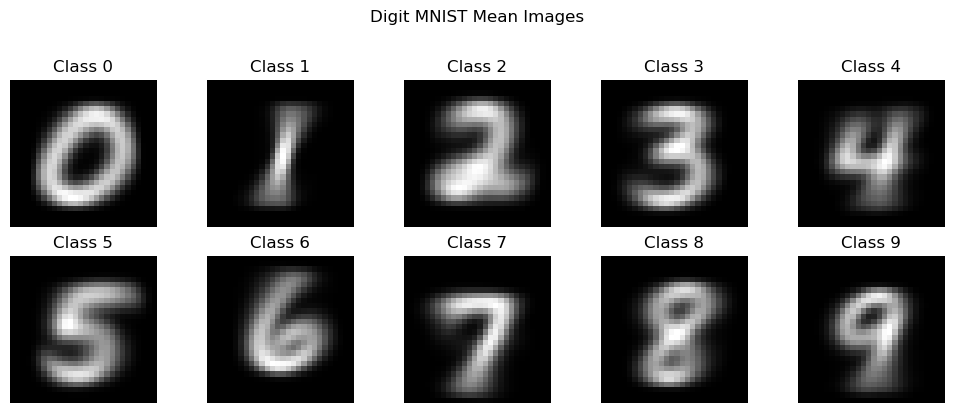

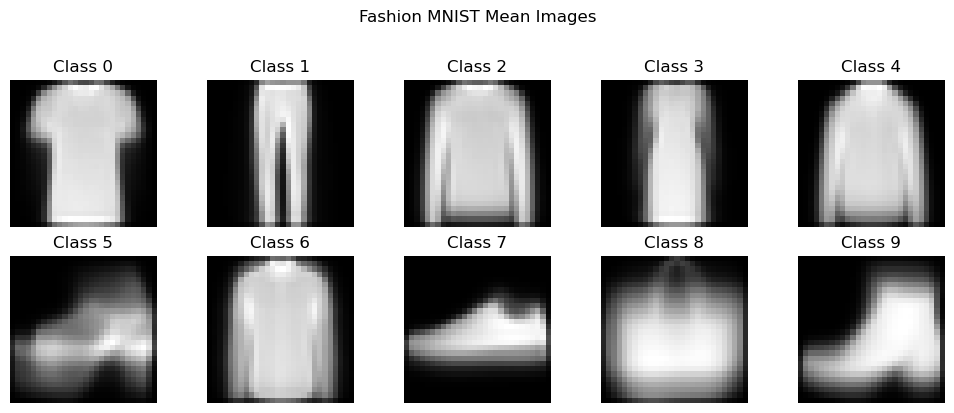

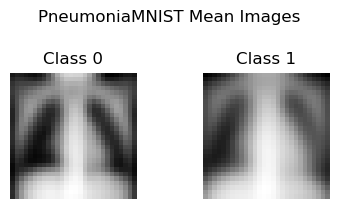

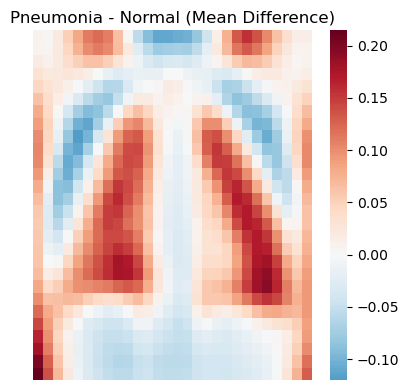

In [12]:
def compute_mean_images(images, labels, num_classes):
    means = []
    for cls in range(num_classes):
        cls_images = images[labels == cls]
        means.append(cls_images.mean(axis=0))
    return np.stack(means)

def plot_mean_grid(mean_images, title, grid_shape, file_name):
    rows, cols = grid_shape
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).reshape(rows, cols)
    for idx, ax in enumerate(axes.ravel()):
        if idx >= len(mean_images):
            ax.axis("off")
            continue
        ax.imshow(mean_images[idx], cmap="gray")
        ax.set_title(f"Class {idx}")
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

digit_means = compute_mean_images(X_digit, y_digit, 10)
fashion_means = compute_mean_images(X_fashion, y_fashion, 10)
pneumonia_means = compute_mean_images(X_pneumonia, y_pneumonia, 2)

plot_mean_grid(digit_means, "Digit MNIST Mean Images", (2, 5), "mean_digit.png")
plot_mean_grid(fashion_means, "Fashion MNIST Mean Images", (2, 5), "mean_fashion.png")
plot_mean_grid(pneumonia_means, "PneumoniaMNIST Mean Images", (1, 2), "mean_pneumonia.png")

diff = pneumonia_means[1] - pneumonia_means[0]
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.heatmap(diff, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Pneumonia - Normal (Mean Difference)")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "pneumonia_difference_heatmap.png", dpi=300)
plt.show()

**Nhan xet:** Anh trung binh giup nhan dien hinh dang lop; heatmap chenhlech nhan man vung phỏi (xem mean_*.png va pneumonia_difference_heatmap.png).

### 5) Canny edge (so sanh dinh tinh)

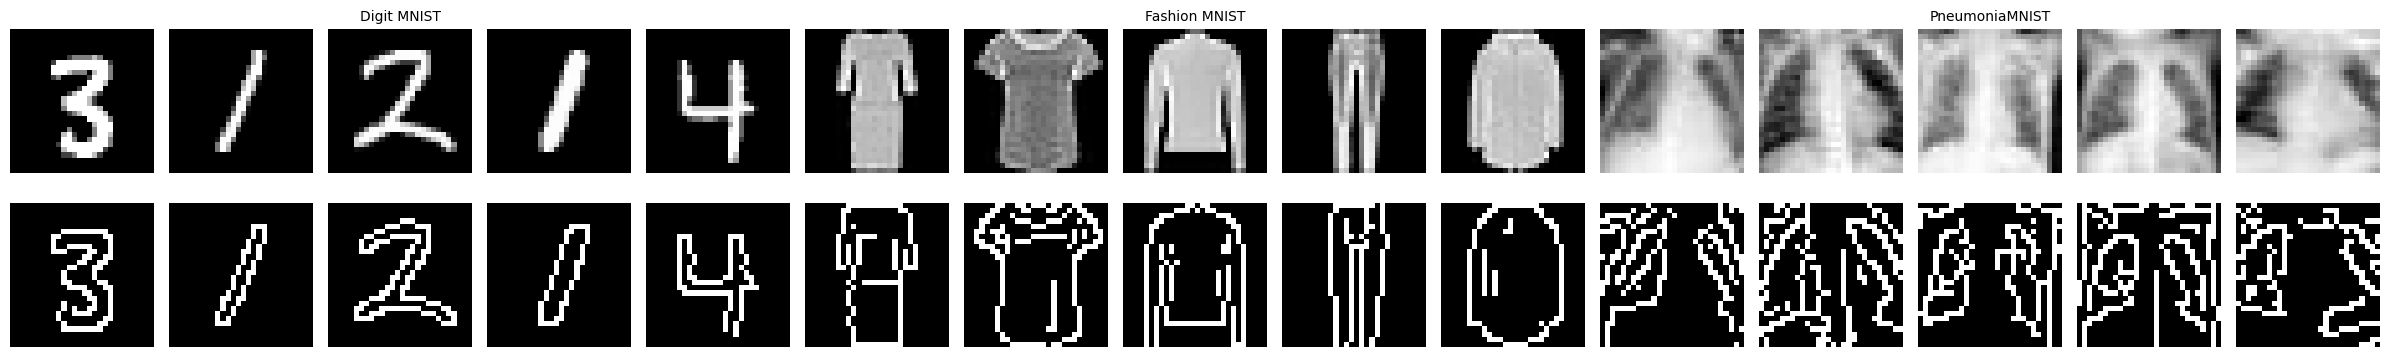

In [13]:
rng = np.random.default_rng(RANDOM_STATE)

digit_idx = rng.choice(len(X_digit), size=5, replace=False)
fashion_idx = rng.choice(len(X_fashion), size=5, replace=False)
pneu_idx = rng.choice(len(X_pneumonia), size=5, replace=False)

selected_images = np.concatenate([X_digit[digit_idx], X_fashion[fashion_idx], X_pneumonia[pneu_idx]])

fig, axes = plt.subplots(2, 15, figsize=(24, 4))
for i, img in enumerate(selected_images):
    img_uint8 = (img * 255).astype("uint8")
    edges = cv2.Canny(img_uint8, threshold1=50, threshold2=150)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(edges, cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", rotation=90, labelpad=10)
axes[1, 0].set_ylabel("Canny", rotation=90, labelpad=10)
axes[0, 2].set_title("Digit MNIST", fontsize=10)
axes[0, 7].set_title("Fashion MNIST", fontsize=10)
axes[0, 12].set_title("PneumoniaMNIST", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "canny_fashion_pneumonia.png", dpi=300)
plt.show()

**Nhan xet:** Vi du minh hoa dinh tinh cho thay bien Digit sac net, Fashion ro rang, PneumoniaMNIST nhieu nhieu va manh tinh texture (xem canny_fashion_pneumonia.png).

### 6) HOG va GLCM

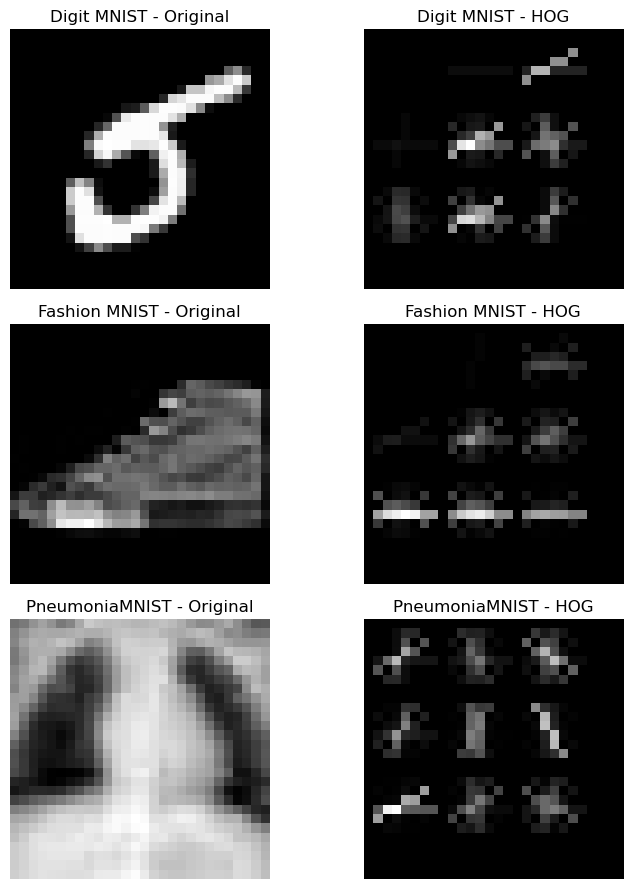

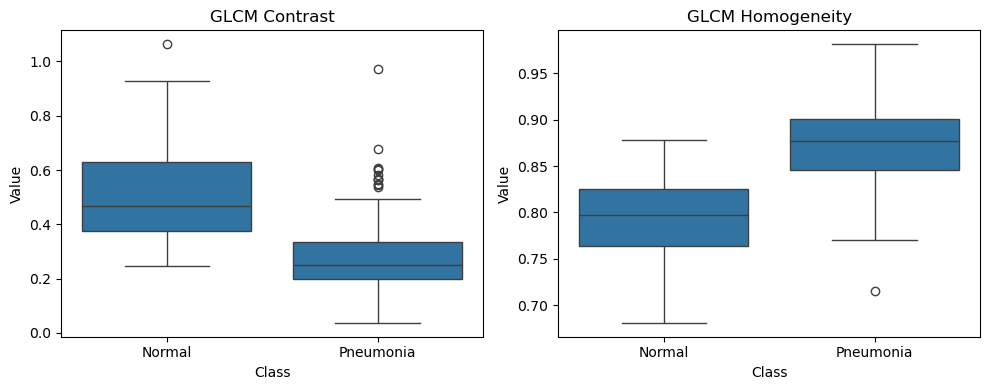

In [14]:
hog_samples = {
    "Digit MNIST": X_digit,
    "Fashion MNIST": X_fashion,
    "PneumoniaMNIST": X_pneumonia,
}

fig, axes = plt.subplots(3, 2, figsize=(8, 9))
for row, (name, images) in enumerate(hog_samples.items()):
    idx = rng.integers(0, len(images))
    img = images[idx]
    hog_features, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        feature_vector=True,
    )
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"{name} - Original")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(hog_image, cmap="gray")
    axes[row, 1].set_title(f"{name} - HOG")
    axes[row, 1].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "hog_comparison.png", dpi=300)
plt.show()

pneu_images = X_pneumonia
pneu_labels = y_pneumonia
normal_idx = np.where(pneu_labels == 0)[0]
pneu_idx = np.where(pneu_labels == 1)[0]
sample_count = 200
normal_sample = rng.choice(normal_idx, size=min(sample_count, len(normal_idx)), replace=False)
pneu_sample = rng.choice(pneu_idx, size=min(sample_count, len(pneu_idx)), replace=False)

def glcm_features(images):
    contrast_vals = []
    homogeneity_vals = []
    for img in images:
        quantized = np.clip(np.round(img * 7), 0, 7).astype("uint8")
        glcm = graycomatrix(
            quantized,
            distances=[1],
            angles=[0],
            levels=8,
            symmetric=True,
            normed=True,
        )
        contrast_vals.append(graycoprops(glcm, "contrast")[0, 0])
        homogeneity_vals.append(graycoprops(glcm, "homogeneity")[0, 0])
    return contrast_vals, homogeneity_vals

normal_contrast, normal_homogeneity = glcm_features(pneu_images[normal_sample])
pneu_contrast, pneu_homogeneity = glcm_features(pneu_images[pneu_sample])

glcm_df = pd.DataFrame(
    {
        "Class": ["Normal"] * len(normal_contrast)
        + ["Pneumonia"] * len(pneu_contrast)
        + ["Normal"] * len(normal_homogeneity)
        + ["Pneumonia"] * len(pneu_homogeneity),
        "Metric": ["Contrast"] * len(normal_contrast)
        + ["Contrast"] * len(pneu_contrast)
        + ["Homogeneity"] * len(normal_homogeneity)
        + ["Homogeneity"] * len(pneu_homogeneity),
        "Value": normal_contrast + pneu_contrast + normal_homogeneity + pneu_homogeneity,
    }
 )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=glcm_df[glcm_df["Metric"] == "Contrast"], x="Class", y="Value", ax=axes[0])
axes[0].set_title("GLCM Contrast")
sns.boxplot(data=glcm_df[glcm_df["Metric"] == "Homogeneity"], x="Class", y="Value", ax=axes[1])
axes[1].set_title("GLCM Homogeneity")
fig.tight_layout()
fig.savefig(FIG_DIR / "glcm_boxplot.png", dpi=300)
plt.show()

**Nhan xet:** HOG ro rang o Digit/Fashion, kem on dinh o PneumoniaMNIST. GLCM goi y texture khac biet giua hai lop (xem hog_comparison.png va glcm_boxplot.png).

### 7) t-SNE + Silhouette (co legend)

c:\Users\duyla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\duyla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\duyla\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\duyla\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

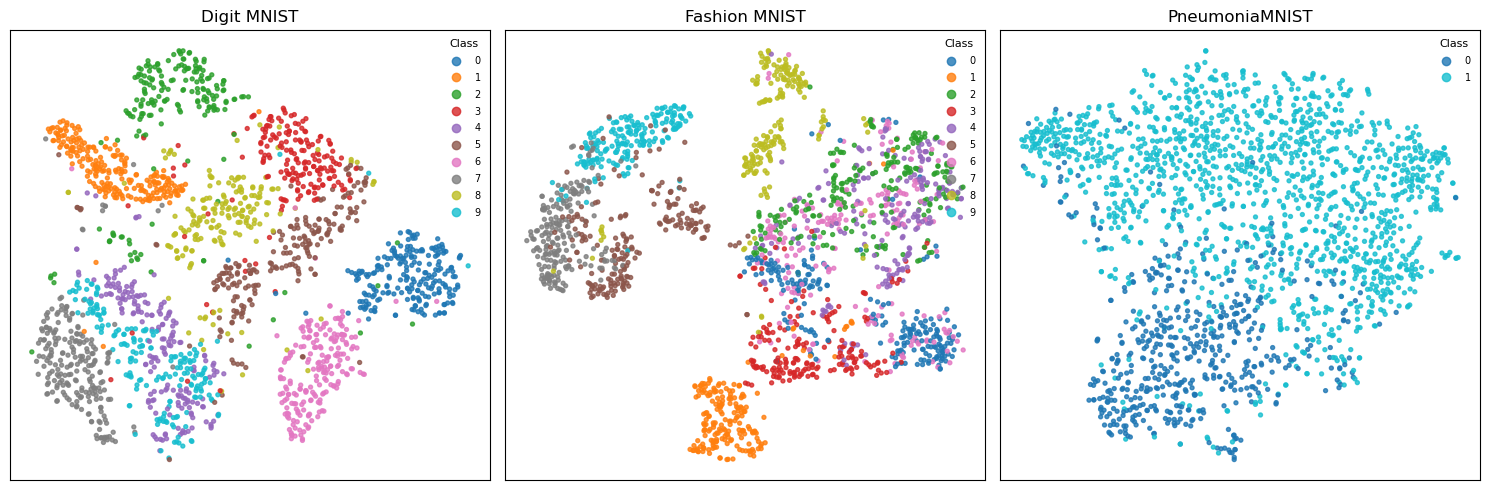

,Dataset,Silhouette
0,Digit MNIST,0.275262
1,Fashion MNIST,0.172927
2,PneumoniaMNIST,0.248507


In [15]:
TSNE_SAMPLES = 2000

datasets_tsne = {
    "Digit MNIST": (X_digit, y_digit),
    "Fashion MNIST": (X_fashion, y_fashion),
    "PneumoniaMNIST": (X_pneumonia, y_pneumonia),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
silhouette_rows = []
for ax, (name, (images, labels)) in zip(axes, datasets_tsne.items()):
    idx = rng.choice(len(images), size=min(TSNE_SAMPLES, len(images)), replace=False)
    sample_images = images[idx].reshape(len(idx), -1)
    sample_labels = labels[idx]
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca")
    embedding = tsne.fit_transform(sample_images)
    scatter = ax.scatter(
        embedding[:, 0], embedding[:, 1], c=sample_labels, cmap="tab10", s=8, alpha=0.8
    )
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    handles, labels_text = scatter.legend_elements()
    ax.legend(handles, labels_text, title="Class", loc="upper right", fontsize=7, title_fontsize=8, frameon=False)
    score = silhouette_score(embedding, sample_labels)
    silhouette_rows.append({"Dataset": name, "Silhouette": score})
fig.tight_layout()
fig.savefig(FIG_DIR / "tsne_comparison.png", dpi=300)
plt.show()
pd.DataFrame(silhouette_rows)

**Nhan xet:** t-SNE giup quan sat cum, nhung Silhouette tren embedding chi nen tham khao vi t-SNE khong bao ton khoang cach toan cuc (xem tsne_comparison.png).

### 8) SSIM (PneumoniaMNIST)

In [16]:
labels = y_pneumonia
images = X_pneumonia
normal_idx = np.where(labels == 0)[0]
pneu_idx = np.where(labels == 1)[0]
pair_count = 100

def sample_pairs(idx_a, idx_b):
    a = rng.choice(idx_a, size=pair_count, replace=True)
    b = rng.choice(idx_b, size=pair_count, replace=True)
    return zip(a, b)

def mean_ssim(pairs):
    scores = []
    for i, j in pairs:
        scores.append(ssim(images[i], images[j], data_range=1.0))
    return float(np.mean(scores))

nn = mean_ssim(sample_pairs(normal_idx, normal_idx))
pp = mean_ssim(sample_pairs(pneu_idx, pneu_idx))
np_score = mean_ssim(sample_pairs(normal_idx, pneu_idx))
pd.DataFrame([{"Normal-Normal": nn, "Pneumonia-Pneumonia": pp, "Normal-Pneumonia": np_score}])

,Normal-Normal,Pneumonia-Pneumonia,Normal-Pneumonia
0,0.536744,0.436718,0.362547


**Nhan xet:** SSIM noi bo thap va SSIM cheo thap cho thay bien thien cao, can dac trung manh hon kieu texture/feature learning.

### 9) Ngoai lai va z-score

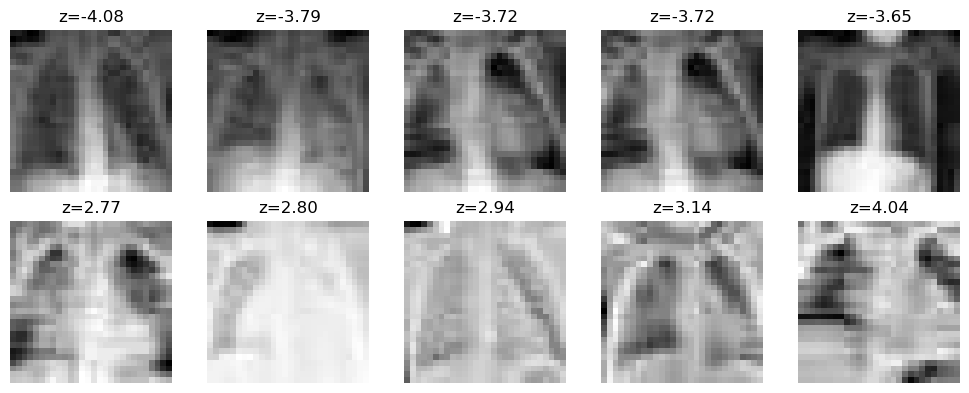

,low_idx,low_z,high_idx,high_z
0,4859,-4.079293,790,2.774899
1,821,-3.794215,4360,2.801149
2,4590,-3.717334,731,2.938142
3,1690,-3.717334,3654,3.144146
4,4426,-3.650386,2377,4.040143


In [17]:
pixel_sums = X_pneumonia.reshape(len(X_pneumonia), -1).sum(axis=1)
mean_sum = pixel_sums.mean()
std_sum = pixel_sums.std()
z_scores = (pixel_sums - mean_sum) / std_sum

sorted_idx = np.argsort(pixel_sums)
low_idx = sorted_idx[:5]
high_idx = sorted_idx[-5:]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, idx in enumerate(low_idx):
    axes[0, i].imshow(X_pneumonia[idx], cmap="gray")
    axes[0, i].set_title(f"z={z_scores[idx]:.2f}")
    axes[0, i].axis("off")
for i, idx in enumerate(high_idx):
    axes[1, i].imshow(X_pneumonia[idx], cmap="gray")
    axes[1, i].set_title(f"z={z_scores[idx]:.2f}")
    axes[1, i].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "pneumonia_outliers.png", dpi=300)
plt.show()

pd.DataFrame({"low_idx": low_idx, "low_z": z_scores[low_idx], "high_idx": high_idx, "high_z": z_scores[high_idx]})

**Nhan xet:** Anh qua toi/qua sang co |z| lon, can luu y tien xu ly (xem pneumonia_outliers.png).

### 10) Tong ket dac trung chi phoi

In [18]:
pd.DataFrame(
    [
        {"Dataset": "MNIST", "Dominant feature": "Shape (strokes)"},
        {"Dataset": "Fashion MNIST", "Dominant feature": "Shape + Structure"},
        {"Dataset": "PneumoniaMNIST", "Dominant feature": "Texture (X-ray)"},
    ]
 )

,Dataset,Dominant feature
0,MNIST,Shape (strokes)
1,Fashion MNIST,Shape + Structure
2,PneumoniaMNIST,Texture (X-ray)
